In [1]:
import joblib
from analysis_utils import *
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd
from imblearn.over_sampling import SMOTE

# Virtualization Settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/titanic.csv")
print(f"1. Data is loaded. Size: {df.shape}")

1. Data is loaded. Size: (891, 12)


In [3]:
# --- 1.2. General Structure ---
check_general_structure(df)

=== Data Types and Non-Null Information ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None

=== Missing Value Summary ===
          Missing Count  Missing Percentage (%)
Age                 177               19.865320
Cabin               687               77.104377
Embarked              2           

,Missing Count,Missing Percentage (%)
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [4]:
# --- 1.3. Numerical - Categorical Column Split ---
numeric_cols = df.select_dtypes(include=["number"]).drop(columns="PassengerId")
categorical_cols = df.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

--- Numerical Column Distribution ---


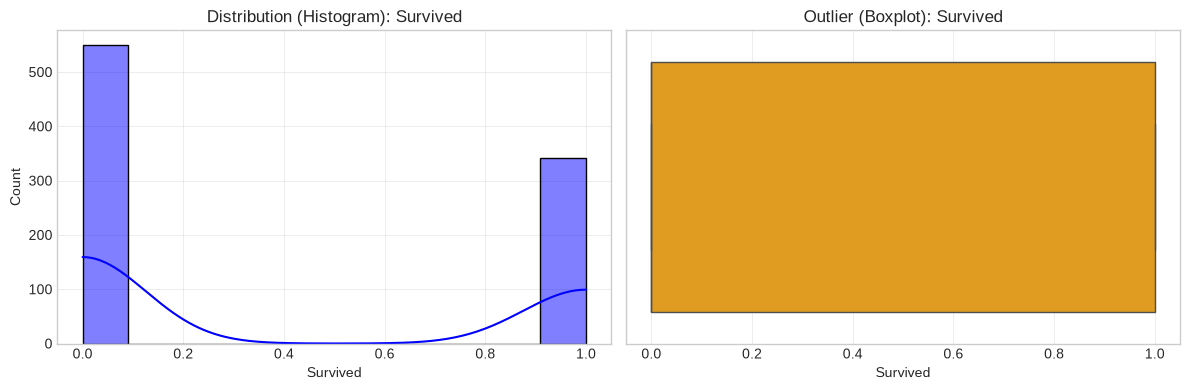

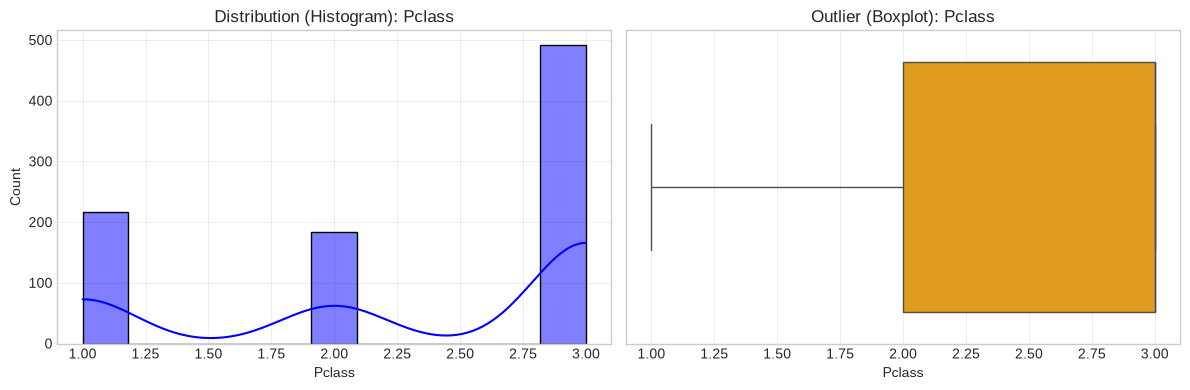

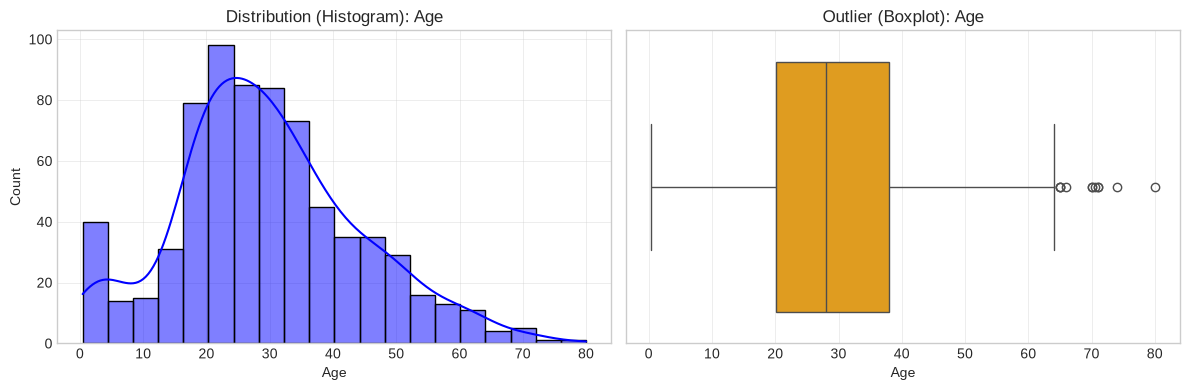

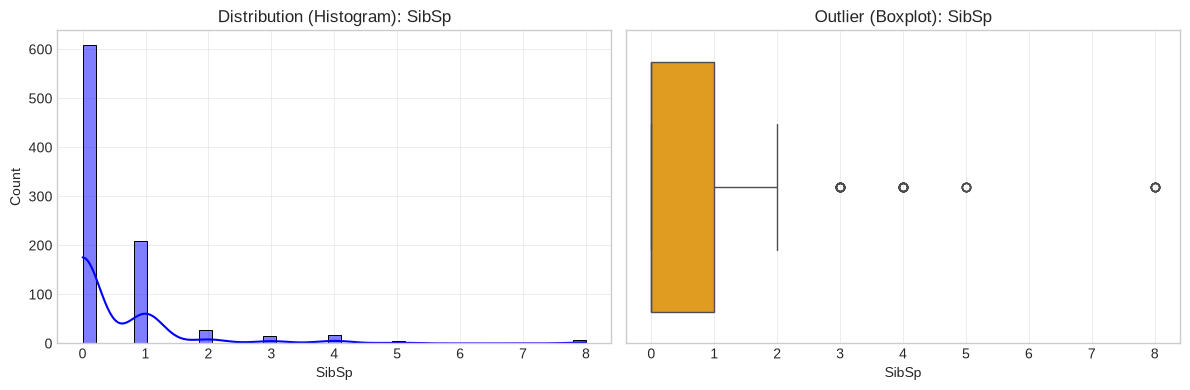

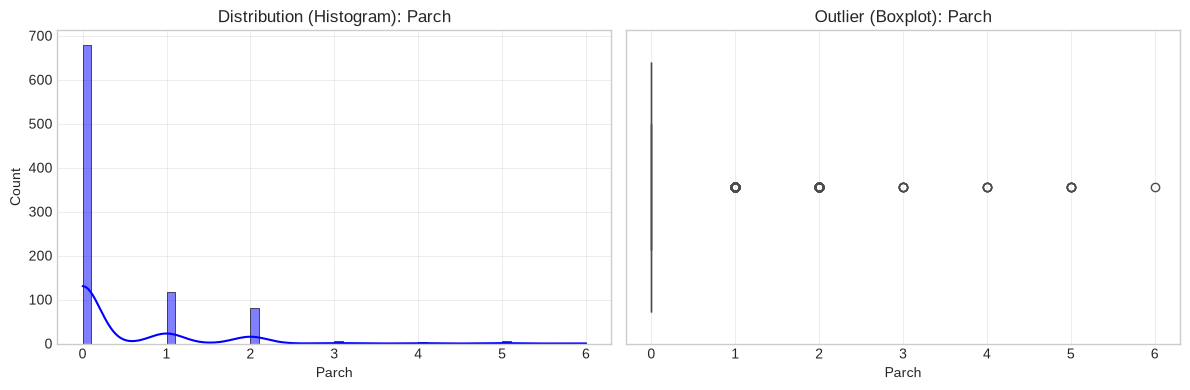

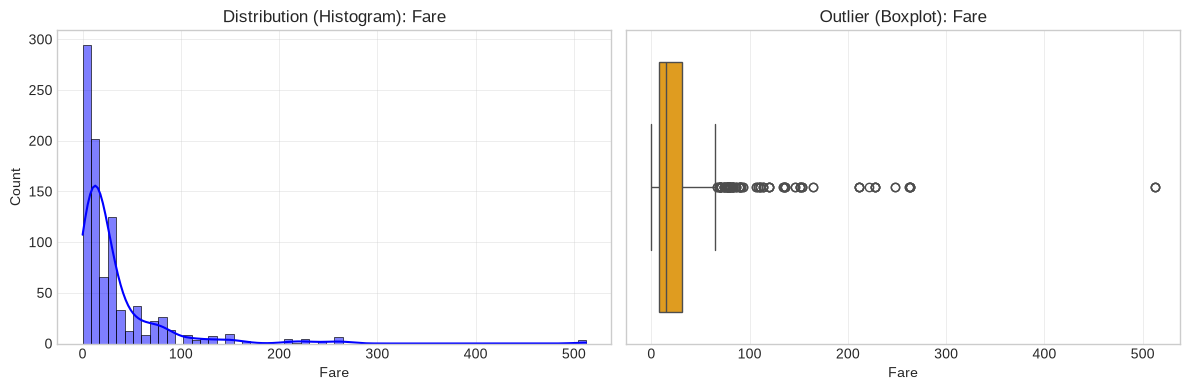

In [5]:
# --- 1.3.1 Numerical Columns ---
print("--- Numerical Column Distribution ---")
plot_statistical_distributions(df, numeric_cols)

--- Categorical Columns Distribution ---


/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

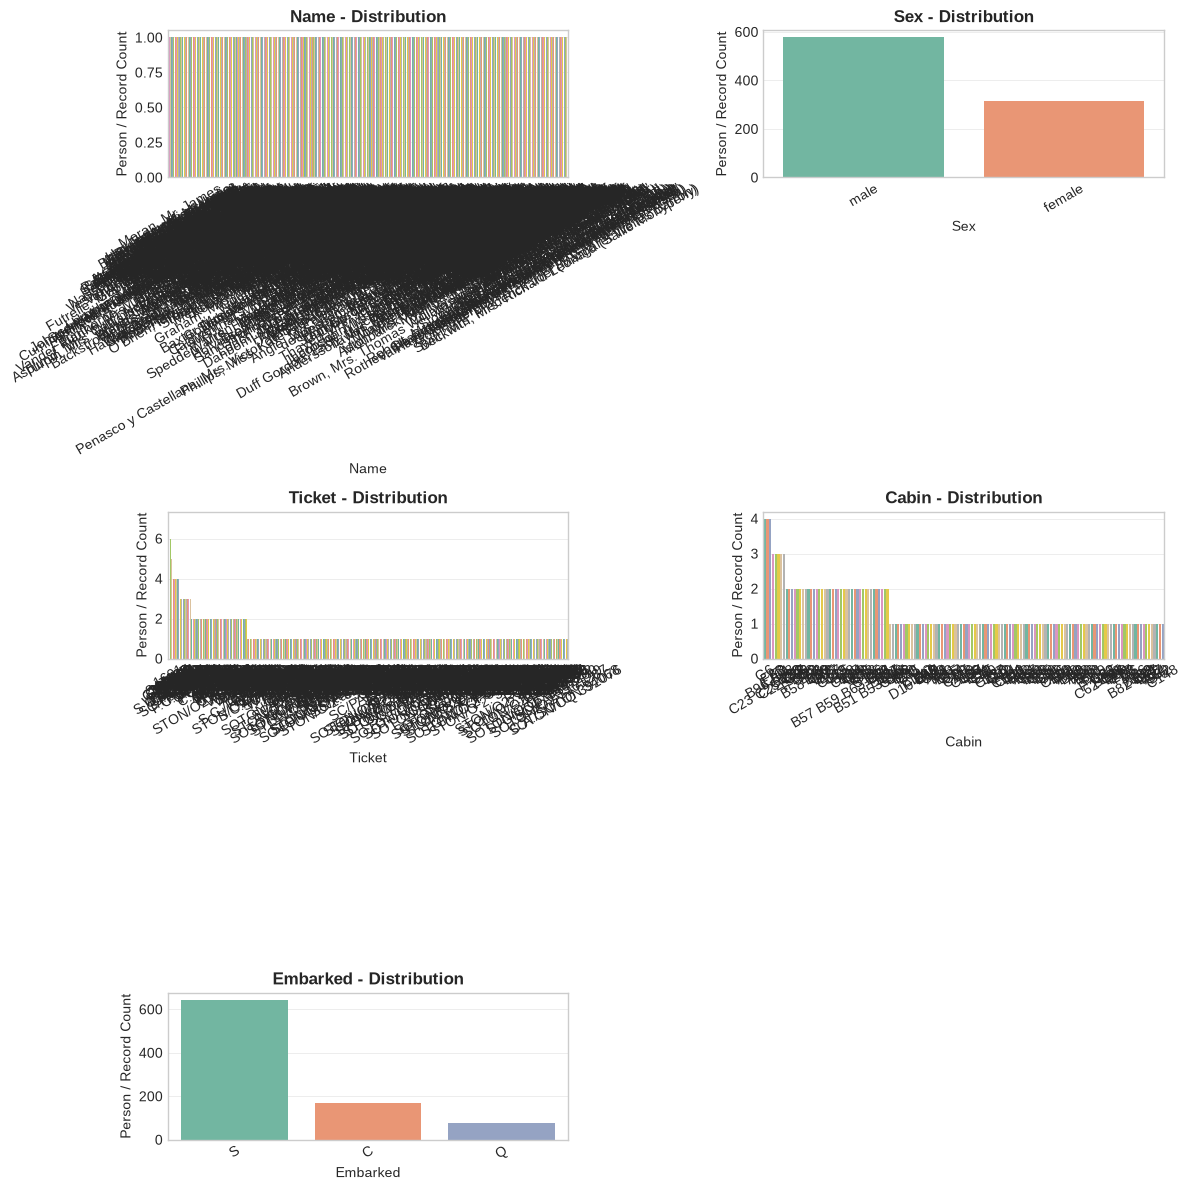

In [6]:
# --- 1.3.2 Categorical Columns ---
print("--- Categorical Columns Distribution ---")
plot_categorical_distributions(df, categorical_cols)

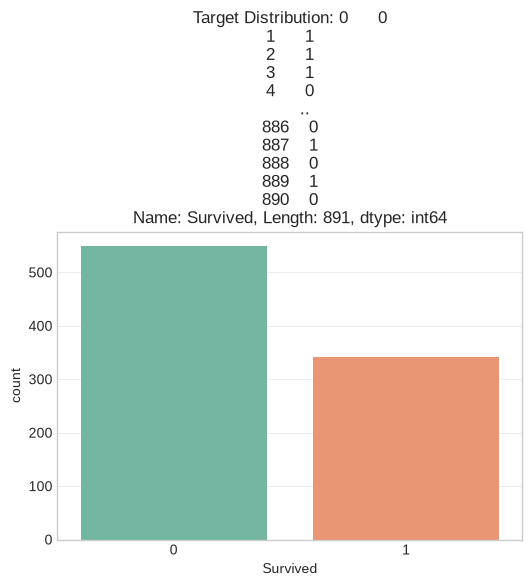

In [7]:
# --- 1.4. Target Distribution ---
target_column = df["Survived"]
plot_target_distribution(df, target_column)

In [8]:
# --- 2. Train - Test Split ---
X = df.drop(columns=["Survived"])
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n2. Data is splitted -> Train: {X_train.shape}, Test: {X_test.shape}")


2. Data is splitted -> Train: (712, 11), Test: (179, 11)


In [9]:
# --- 2.2. Clearing Constant Columns ---
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

if constant_cols:
    print(f"Constant columns are detected and removed: {constant_cols}")
    X_train_cleared = X_train.drop(columns=constant_cols)
    X_test_cleared = X_test.drop(columns=constant_cols)
else:
    print("No constant columns are detected.")

No constant columns are detected.


In [10]:
# --- 2.3. Feature Extraction ---
# Train Data
X_train["Title"] = X_train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
rare_titles = [
    "Capt",
    "Col",
    "Don",
    "Dr",
    "Major",
    "Rev",
    "Jonkheer",
    "Dona",
    "Lady",
    "Countess",
    "Sir",
]
X_train["Title"] = X_train["Title"].replace(rare_titles, "Rare")
X_train["Title"] = X_train["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
X_train = X_train.drop(columns="Name")

# Test Data
X_test["Title"] = X_test["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
X_test["Title"] = X_test["Title"].replace(rare_titles, "Rare")
X_test["Title"] = X_test["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
X_test = X_test.drop(columns="Name")

In [11]:
# --- 3.1. Missing Value Handling (X_train) ---
# --- 3.1.1 Missing Values of Age ---
X_train["Age"] = X_train["Age"].fillna(X_train.groupby("Title")["Age"].transform("median"))

# --- 3.1.2 Missing Values of Embarked ---
X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].mode()[0])

# --- 3.1.3 Filling Missing Values of Cabin with "Unknown" ---
X_train["Cabin_Deck"] = X_train["Cabin"].str[0].fillna("U")

# --- 3.1.4 Dropping Unnecessary Columns ---
X_train = X_train.drop(columns=["Cabin","Ticket"])

# --- 3.2. Missing Value Handling (X_test) ---
# --- 3.2.1. Age: Apply Title-based medians calculated from the training set to the test set ---
title_medians = X_train.groupby("Title")["Age"].median()
X_test["Age"] = X_test["Age"].fillna(X_test["Title"].map(title_medians))

# --- 3.2.2 If a new Title appears in the test set that was never in the training set and NaNs remain, fill with the overall X_train age median ---
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())

# --- 3.2.3. Embarked: Use the mode value of the training set ---
embarked_mode = X_train["Embarked"].mode()[0]
X_test["Embarked"] = X_test["Embarked"].fillna(embarked_mode)

# --- 3.2.4. Cabin: Extract the cabin initial and fill with "U" ---
X_test["Cabin_Deck"] = X_test["Cabin"].str[0].fillna("U")

# 3.2.5 Dropping Unnecessary Columns
X_test = X_test.drop(columns=["Cabin","Ticket"])

In [12]:
# --- 4. Encoding Categorical Columns ---
categorical_cols = [col for col in categorical_cols if col in X_train.columns]
encoders = {}

train_encoded_list = []
test_encoded_list = []

for col in categorical_cols:
  encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
  # For Train Set
  train_arr = encoder.fit_transform(X_train[[col]])
  train_df = pd.DataFrame(
    train_arr,
    columns=encoder.get_feature_names_out([col]),
    index=X_train.index,
  )

  train_encoded_list.append(train_df)

  # For Test Set
  test_arr = encoder.transform(X_test[[col]])
  test_df = pd.DataFrame(
      test_arr,
      columns=encoder.get_feature_names_out([col]),
      index=X_test.index,
  )
  test_encoded_list.append(test_df)

  encoders[col] = encoder

  # Concat encoded columns and drop original columns
X_train_encoded = pd.concat(
    [X_train.drop(columns=categorical_cols), pd.concat(train_encoded_list, axis=1)],
    axis=1,
)
X_test_encoded = pd.concat(
    [X_test.drop(columns=categorical_cols), pd.concat(test_encoded_list, axis=1)],
    axis=1,
)

In [13]:
# --- 5. Outlier Detection ---
X_train_clipped, X_test_clipped, outlier_summary = apply_iqr_clipping(X_train_encoded, X_test, numeric_cols)

=== Outlier Counts ===
🔸 Age: Found 29 outliers.
🔸 SibSp: Found 33 outliers.
🔸 Parch: Found 170 outliers.
🔸 Fare: Found 91 outliers.
8. IQR Clipping Process Completed (Factor: 1.5).


In [14]:
# --- 6. Yeo-Johnson for Skewness ---
numerical_cols = ["Pclass","Age","SibSp","Parch","Fare"]
X_train_yeo, X_test_yeo, pt = apply_yeo_johnson(X_train_clipped, X_test_clipped, numerical_cols)

7. Yeo-Johnson transformation is applied successfully and test set is protected (Data Leakage is blocked).


In [15]:
# --- 7. Correlation Filter (After Clipping) ---
X_train_corr, X_test_corr = correlation_filter(
    X_train_yeo, X_test_yeo, corr_threshold=0.7
)

9. Remaining Feature Count After Correlation Filter: 11


In [16]:
# --- 8. Feature Selection ---

X_train_encoded = pd.get_dummies(X_train_corr, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_corr, drop_first=True)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0
)

selected_features = select_best_features_anova_string(
    X_train_encoded, y_train, k=5
)

selected_features = [
    f
    for f in selected_features
    if f is not None and pd.notna(f) and f in X_test_encoded.columns
]

X_train_selected = X_train_encoded[selected_features]
X_test_selected = X_test_encoded[selected_features]

=== Top 5 Features (ANOVA) ===
         Feature       Score
10      Title_Mr  317.016763
6     Sex_female  306.593249
5           Fare  100.273172
20  Cabin_Deck_U   99.462219
11     Title_Mrs   97.430906


/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [4] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/gokay/PycharmProjects/FastApiProject/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


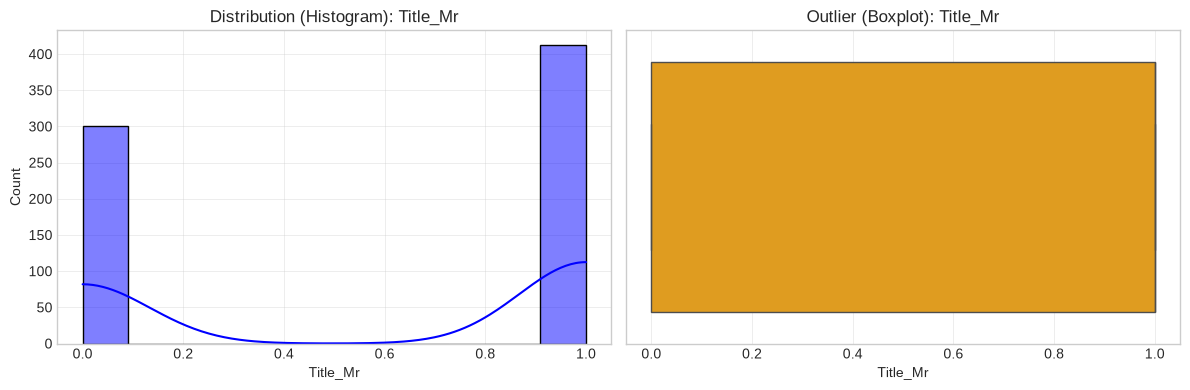

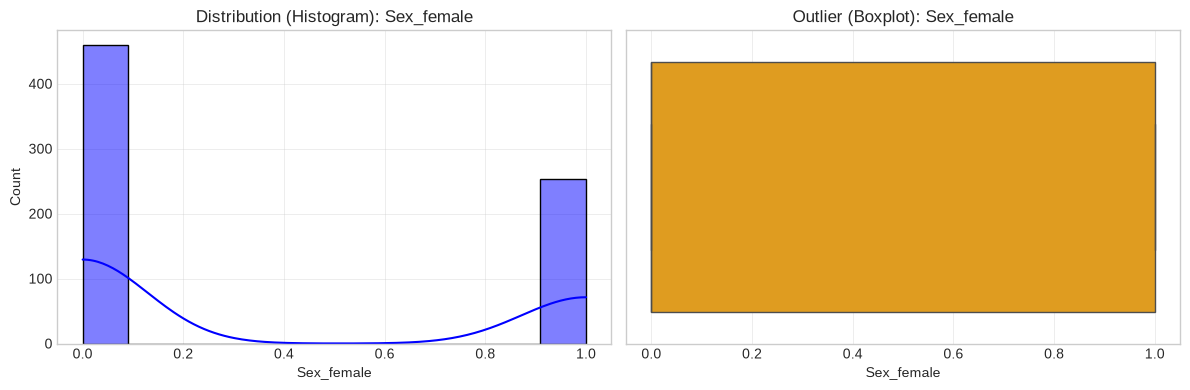

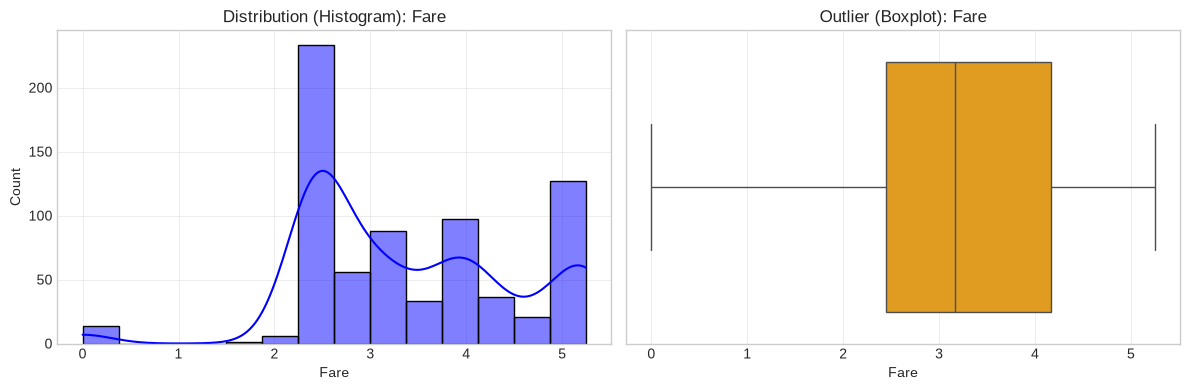

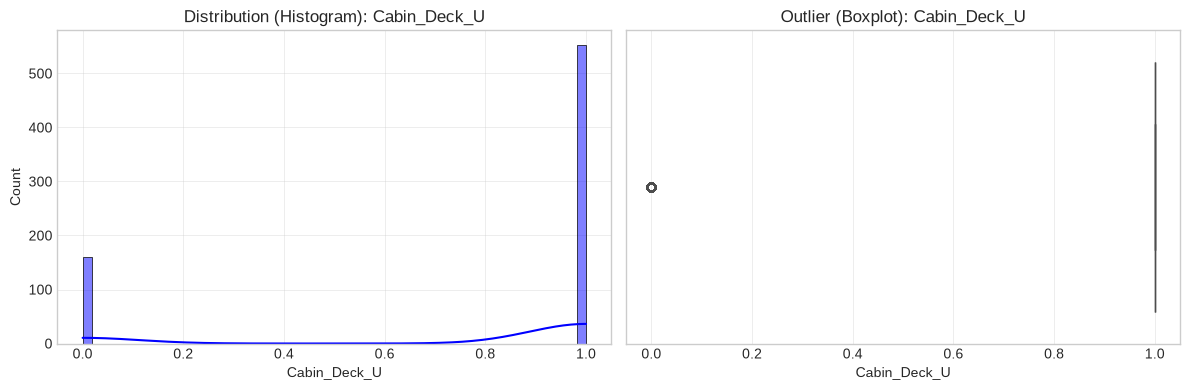

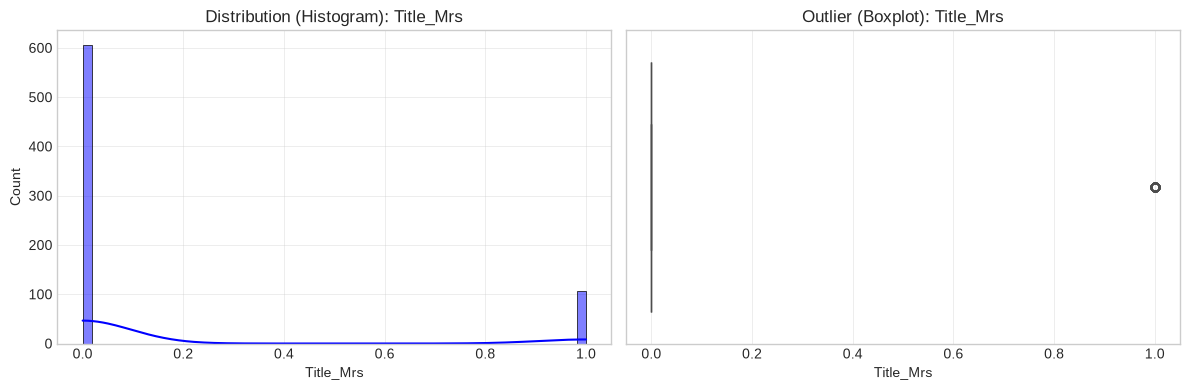

In [17]:
# --- 9. Virtualization
plot_statistical_distributions(X_train_selected, selected_features)

In [18]:
# --- 10. Scaling ---
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

In [19]:
# --- 11.1. SMOTE object creation ---
smote = SMOTE(random_state=42)

# 11.2. Duplicating only train data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_selected, y_train
)

# 11.3. Converting back to DataFrame
X_train_resampled = pd.DataFrame(
    X_train_resampled, columns=selected_features
)

print(f"Old Train Size: {X_train_selected.shape}")
print(f"New Train Size (After SMOTE) - Row: {X_train_resampled.shape[0]}, Column: {X_train_resampled.shape[1]}")

Old Train Size: (712, 5)
New Train Size (After SMOTE) - Satır: 878, Sütun: 5


In [20]:
bundle = {
    "X_train": X_train_resampled,
    "y_train": y_train_resampled,
    "X_test": X_test_selected,
    "y_test": y_test,
    "encoders": encoders,
    "power_transformer": pt,
    "scaler": scaler,
    "selected_features": selected_features,
    "title_medians": title_medians,
    "age_median": X_train["Age"].median(),
    "embarked_mode": embarked_mode,
}
joblib.dump(bundle, "../backend/models/titanic/titanic_data_bundle.pkl")
print("Pipeline bundle successfully saved!")

Pipeline bundle successfully saved!
